In [42]:
# Localization_Regression.ipynb
import os
import numpy as np
import pandas as pd
import pydicom
import matplotlib.pyplot as plt
import vision_models.constants as constants
from pydicom.pixel_data_handlers.util import apply_modality_lut
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from keras import layers, models, applications, losses

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import tensorflow as tf
from keras import layers, models, applications, losses
from sklearn.metrics import confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report


import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import tensorflow as tf
from keras import layers, models, applications, losses
from sklearn.metrics import mean_squared_error, mean_absolute_error

import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import tensorflow as tf
from keras import layers, models, applications, losses
from sklearn.metrics import mean_squared_error, mean_absolute_error



In [73]:
epoch_var = 10

In [64]:
# Set paths
train_images_path = constants.TRAIN_DATA_PATH
train_df = pd.read_csv("NEW_EDA/train_dataset.csv")
val_df = pd.read_csv("NEW_EDA/val_dataset.csv")
test_df = pd.read_csv("NEW_EDA/test_dataset.csv")

# # One-hot encode the 'condition' and 'level' columns separately
# train_condition_dummies = pd.get_dummies(train_df['condition'], prefix='condition')
# train_level_dummies = pd.get_dummies(train_df['level'], prefix='level')

# val_condition_dummies = pd.get_dummies(val_df['condition'], prefix='condition')
# val_level_dummies = pd.get_dummies(val_df['level'], prefix='level')

# test_condition_dummies = pd.get_dummies(test_df['condition'], prefix='condition')
# test_level_dummies = pd.get_dummies(test_df['level'], prefix='level')

# # Concatenate the dummy columns back to the original DataFrame
# train_df = pd.concat([train_df.drop(['condition', 'level'], axis=1), train_condition_dummies, train_level_dummies], axis=1)
# val_df = pd.concat([val_df.drop(['condition', 'level'], axis=1), val_condition_dummies, val_level_dummies], axis=1)
# test_df = pd.concat([test_df.drop(['condition', 'level'], axis=1), test_condition_dummies, test_level_dummies], axis=1)

# Now you have your DataFrame with one-hot encoded columns for 'condition' and 'level'


In [65]:
# Filter out rows with NaN values in x and y coordinates
train_df = train_df.dropna(subset=['x', 'y'])
val_df = val_df.dropna(subset=['x', 'y'])
test_df = test_df.dropna(subset=['x', 'y'])

# Check the shapes of the filtered datasets
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)


(38931, 38)
(4844, 38)
(4917, 38)


In [76]:
train_df = train_df.sample(frac=0.50, random_state=42)
val_df = val_df.sample(frac=0.50, random_state=42)
test_df = test_df.sample(frac=0.50, random_state=42)

train_df

In [67]:


# Data Preparation
for df in [train_df, val_df, test_df]:
    df['image_path'] = df.apply(lambda row: os.path.join(train_images_path, str(row['study_id']), str(row['series_id']), f"{row['instance_number']}.dcm"), axis=1)


In [68]:
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(19466, 39)
(2422, 39)
(2458, 39)


In [69]:
# Keep only the necessary columns for the regression task
columns_to_keep = ['image_path', 'x', 'y']

# Drop all other columns
train_df = train_df[columns_to_keep]
val_df = val_df[columns_to_keep]
test_df = test_df[columns_to_keep]

print(train_df.columns)  # Check the remaining columns to ensure correctness
print(val_df.columns)
print(test_df.columns)


Index(['image_path', 'x', 'y'], dtype='object')
Index(['image_path', 'x', 'y'], dtype='object')
Index(['image_path', 'x', 'y'], dtype='object')


In [70]:

# Function to read and preprocess images using pydicom
def load_image(img_path, target_size=(224, 224)):
    # Load DICOM file
    dicom = pydicom.dcmread(img_path.numpy().decode('utf-8'))
    img = dicom.pixel_array
    
    # Normalize the image
    img = img / np.max(img)
    
    # Ensure img has 3 dimensions (Height, Width, Channels)
    if len(img.shape) == 2:  # Grayscale image
        img = np.expand_dims(img, axis=-1)  # Add channel dimension
    
    # Convert grayscale to RGB (3 channels) if needed
    if img.shape[-1] == 1:
        img = np.concatenate([img, img, img], axis=-1)
    
    # Convert to float32 immediately
    img = tf.convert_to_tensor(img, dtype=tf.float32)
    
    # Now resize the image
    img = tf.image.resize(img, target_size)
    
    # Normalize pixel values to [0, 1]
    img = img / 255.0
    
    return img

# Wrapper function to use with tf.data.Dataset.map
def load_image_wrapper(img_path, target_size=(224, 224)):
    img = tf.py_function(func=load_image, inp=[img_path], Tout=tf.float32)
    img.set_shape((target_size[0], target_size[1], 3))  # Explicitly set shape (224, 224, 3)
    return img

# Create a TensorFlow dataset for the regression task
def create_tf_dataset(df, batch_size=32, is_training=True):
    # Labels are the x and y coordinates for the regression task
    label_columns = ['x', 'y']
    
    dataset = tf.data.Dataset.from_tensor_slices((df['image_path'], df[label_columns]))
    dataset = dataset.map(lambda x, y: (load_image_wrapper(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    
    # Debugging: Print shape of each element in the dataset
    def print_shapes(x, y):
        print(f"Image shape: {x.shape}, Label shape: {y.shape}")
        return x, y
    
    dataset = dataset.map(print_shapes)  # Add this line to print shapes
    
    if is_training:
        dataset = dataset.shuffle(buffer_size=1024)
    dataset = dataset.batch(batch_size).prefetch(buffer_size=tf.data.AUTOTUNE)
    return dataset

# Example of creating datasets
train_dataset = create_tf_dataset(train_df)
val_dataset = create_tf_dataset(val_df, is_training=False)
test_dataset = create_tf_dataset(test_df, is_training=False)



Image shape: (224, 224, 3), Label shape: (2,)
Image shape: (224, 224, 3), Label shape: (2,)
Image shape: (224, 224, 3), Label shape: (2,)


In [71]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import tensorflow as tf
from keras import layers, models, applications, losses
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Ensure the directory exists
def ensure_directory(directory):
    if not os.path.exists(directory):
        os.makedirs(directory)

# Plot training history
def plot_metrics(history, title):
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{title} Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    save_path = f'NEW_EDA/{title}.png'
    ensure_directory(os.path.dirname(save_path))  # Ensure the directory exists
    plt.savefig(save_path)
    plt.close()  # Close the plot to ensure it's saved
    print(f"Training history saved at {save_path}")

# Function to save MAE and RMSE to CSV
def save_metrics_to_csv(mae, rmse, dataset_name, model_type):
    # Create a DataFrame with MAE and RMSE
    metrics_df = pd.DataFrame({
        'dataset_name': [dataset_name],
        'model_type': [model_type],
        'mae': [mae],
        'rmse': [rmse]
    })
    
    # Define the save path
    save_path = f'NEW_EDA/{dataset_name}_{model_type}_REG_metrics.csv'
    ensure_directory(os.path.dirname(save_path))  # Ensure the directory exists
    
    # Save to CSV
    if os.path.exists(save_path):
        # Append if file exists
        metrics_df.to_csv(save_path, mode='a', header=False, index=False)
    else:
        # Write with header if file does not exist
        metrics_df.to_csv(save_path, index=False)
    
    print(f"Metrics for {dataset_name} ({model_type}) saved successfully!")

# Function to save predictions and actual labels to CSV
def save_predictions_to_csv(true_coords, predicted_coords, df, dataset_name, model_type):
    # Create a DataFrame with true and predicted coordinates
    results_df = pd.DataFrame({
        'image_path': df['image_path'],
        'true_x': true_coords[:, 0],
        'true_y': true_coords[:, 1],
        'predicted_x': predicted_coords[:, 0],
        'predicted_y': predicted_coords[:, 1]
    })
    
    # Save to CSV
    save_path = f'NEW_EDA/{dataset_name}_{model_type}_REG_predictions.csv'
    ensure_directory(os.path.dirname(save_path))  # Ensure the directory exists
    results_df.to_csv(save_path, index=False)
    print(f"{dataset_name}_{model_type}_predictions.csv saved successfully!")

# Evaluate the model and plot the results
def evaluate_model(model, dataset, df, dataset_name, model_type):
    # Get the true coordinates from the dataset
    true_coords = df[['x', 'y']].values
    
    # Make predictions
    predicted_coords = model.predict(dataset)
    
    # Calculate error metrics
    mae = mean_absolute_error(true_coords, predicted_coords)
    rmse = np.sqrt(mean_squared_error(true_coords, predicted_coords))
    
    print(f"Evaluation on {dataset_name} Data:")
    print(f"MAE: {mae}")
    print(f"RMSE: {rmse}")

    # Save MAE and RMSE to CSV
    save_metrics_to_csv(mae, rmse, dataset_name, model_type)
    
    # Save predictions and actual coordinates to CSV
    save_predictions_to_csv(true_coords, predicted_coords, df, dataset_name, model_type)

# Function to create the CNN model for regression
def create_cnn_regression_model():
    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(2, activation='linear')  # Output layer with 2 neurons for x and y
    ])
    return model

# Function to create the ResNet model for regression
def create_resnet_regression_model():
    base_model = applications.ResNet50(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
    base_model.trainable = False
    
    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)
    output = layers.Dense(2, activation='linear')(x)  # Output layer with 2 neurons for x and y
    
    model = models.Model(inputs=base_model.input, outputs=output)
    return model

# Function to dynamically create and train a model
def run_regression_model(model_type, train_df, val_df, test_df):
    if model_type == 'cnn':
        model = create_cnn_regression_model()
    elif model_type == 'resnet':
        model = create_resnet_regression_model()

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    train_dataset = create_tf_dataset(train_df)
    val_dataset = create_tf_dataset(val_df, is_training=False)
    test_dataset = create_tf_dataset(test_df, is_training=False)

    history = model.fit(train_dataset, validation_data=val_dataset, epochs=epoch_var)
    
    title_suffix = f"{model_type.upper()} Model - Regression"
    plot_metrics(history, f"Training History for {title_suffix}")

    # Evaluate and save predictions for validation and test datasets
    evaluate_model(model, val_dataset, val_df, "Validation", model_type)
    evaluate_model(model, test_dataset, test_df, "Test", model_type)




In [74]:

# Example usage:
run_regression_model('cnn', train_df, val_df, test_df)  # Predict coordinates using CNN
run_regression_model('resnet', train_df, val_df, test_df)  # Predict coordinates using ResNet


Image shape: (224, 224, 3), Label shape: (2,)
Image shape: (224, 224, 3), Label shape: (2,)
Image shape: (224, 224, 3), Label shape: (2,)
Epoch 1/10


2024-08-14 05:22:51.414367: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:319: Filling up shuffle buffer (this may take a while): 892 of 1024
2024-08-14 05:22:52.749604: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


609/609 ━━━━━━━━━━━━━━━━━━━━ 282s 439ms/step - loss: 11804.8662 - mae: 82.1995 - val_loss: 6625.8975 - val_mae: 64.9764
Epoch 2/10


2024-08-14 05:27:30.968760: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:319: Filling up shuffle buffer (this may take a while): 877 of 1024
2024-08-14 05:27:32.485160: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


609/609 ━━━━━━━━━━━━━━━━━━━━ 278s 437ms/step - loss: 7196.8711 - mae: 67.0347 - val_loss: 6939.5601 - val_mae: 67.6565
Epoch 3/10


...

609/609 ━━━━━━━━━━━━━━━━━━━━ 303s 476ms/step - loss: 7076.4497 - mae: 66.4617 - val_loss: 6650.3193 - val_mae: 65.5960
Epoch 9/10


2024-08-14 06:51:25.220126: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:338: Filling up shuffle buffer (this may take a while): 870 of 1024
2024-08-14 06:51:26.767037: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


609/609 ━━━━━━━━━━━━━━━━━━━━ 308s 487ms/step - loss: 7080.2695 - mae: 66.5157 - val_loss: 6655.0015 - val_mae: 65.6397
Epoch 10/10


2024-08-14 06:56:33.279773: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:338: Filling up shuffle buffer (this may take a while): 835 of 1024
2024-08-14 06:56:35.416718: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


609/609 ━━━━━━━━━━━━━━━━━━━━ 305s 481ms/step - loss: 7077.0806 - mae: 66.3784 - val_loss: 6757.0640 - val_mae: 66.4236
Training history saved at NEW_EDA/Training History for RESNET Model - Regression.png
76/76 ━━━━━━━━━━━━━━━━━━━━ 40s 466ms/step
Evaluation on Validation Data:
MAE: 66.42362606369306
RMSE: 82.2013656597963
Metrics for Validation (resnet) saved successfully!
Validation_resnet_predictions.csv saved successfully!
77/77 ━━━━━━━━━━━━━━━━━━━━ 36s 466ms/step
Evaluation on Test Data:
MAE: 66.63494289594733
RMSE: 82.17507221191238
Metrics for Test (resnet) saved successfully!
Test_resnet_predictions.csv saved successfully!


NEW_EDA/Regression_CNN_10epoch_0.50data/Test_cnn_REG_predictions.csv


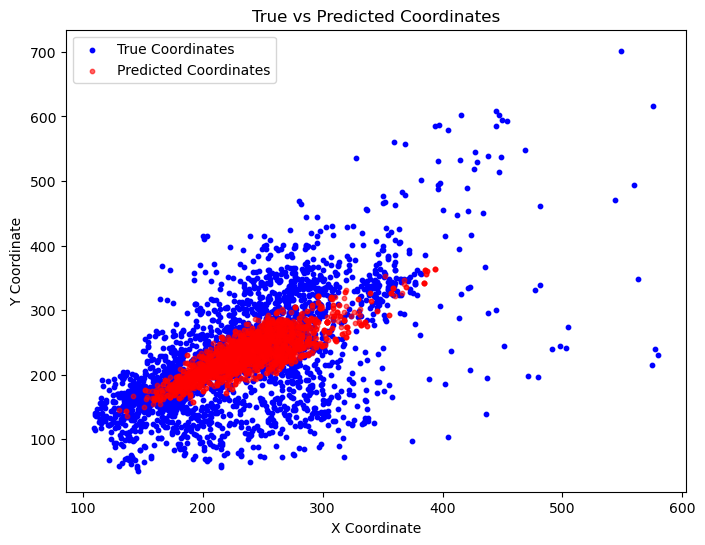

NEW_EDA/Regression_CNN_10epoch_0.50data/Validation_cnn_REG_predictions.csv


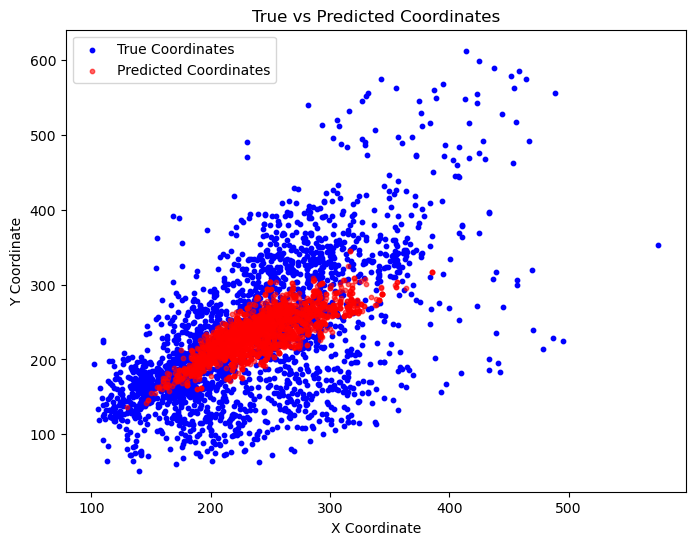

NEW_EDA/Regression_ResNet_10epoch_0.50data/Test_resnet_REG_predictions.csv


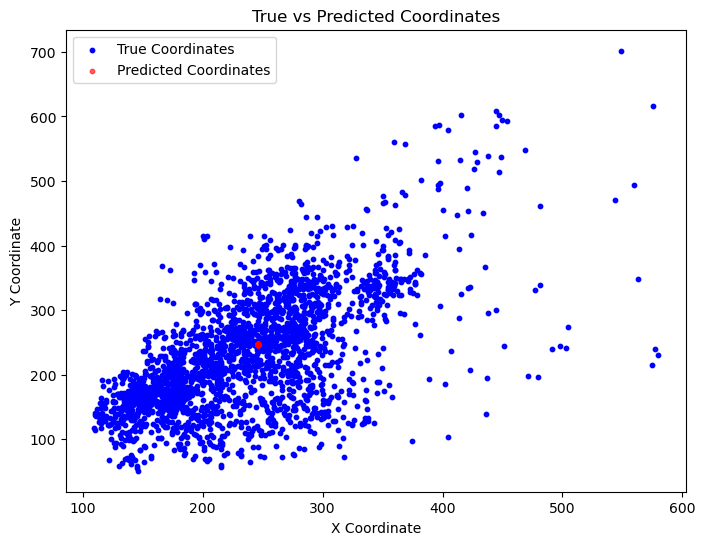

NEW_EDA/Regression_ResNet_10epoch_0.50data/Validation_resnet_REG_predictions.csv


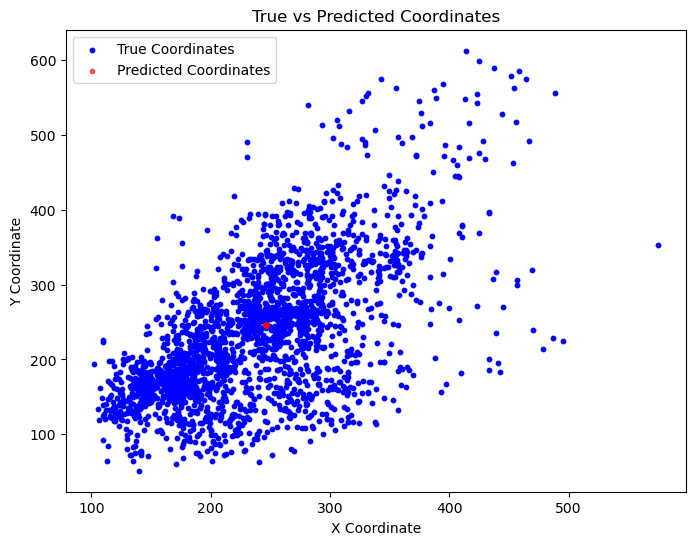

In [75]:
import pandas as pd
import matplotlib.pyplot as plt

files = ['NEW_EDA/Regression_CNN_10epoch_0.50data/Test_cnn_REG_predictions.csv'
         ,'NEW_EDA/Regression_CNN_10epoch_0.50data/Validation_cnn_REG_predictions.csv'
         ,'NEW_EDA/Regression_ResNet_10epoch_0.50data/Test_resnet_REG_predictions.csv'
         ,'NEW_EDA/Regression_ResNet_10epoch_0.50data/Validation_resnet_REG_predictions.csv']

# # Load the CSV file
# csv_path = "NEW_EDA/Test_cnn_REG_predictions.csv"

for i in files:
    print(i)
    csv_path = i
    df = pd.read_csv(csv_path)

    # Extract the true and predicted coordinates
    true_coords = df[['true_x', 'true_y']].values
    predicted_coords = df[['predicted_x', 'predicted_y']].values

    # Create the scatter plot
    def plot_true_vs_predicted(true_coords, predicted_coords, title='True vs Predicted Coordinates'):
        plt.figure(figsize=(8, 6))
        plt.scatter(true_coords[:, 0], true_coords[:, 1], color='blue', label='True Coordinates', s=10)
        plt.scatter(predicted_coords[:, 0], predicted_coords[:, 1], color='red', label='Predicted Coordinates', alpha=0.6, s=10)
        plt.title(title)
        plt.xlabel('X Coordinate')
        plt.ylabel('Y Coordinate')
        plt.legend()
        plt.show()

    # Call the function with your data
    plot_true_vs_predicted(true_coords, predicted_coords)


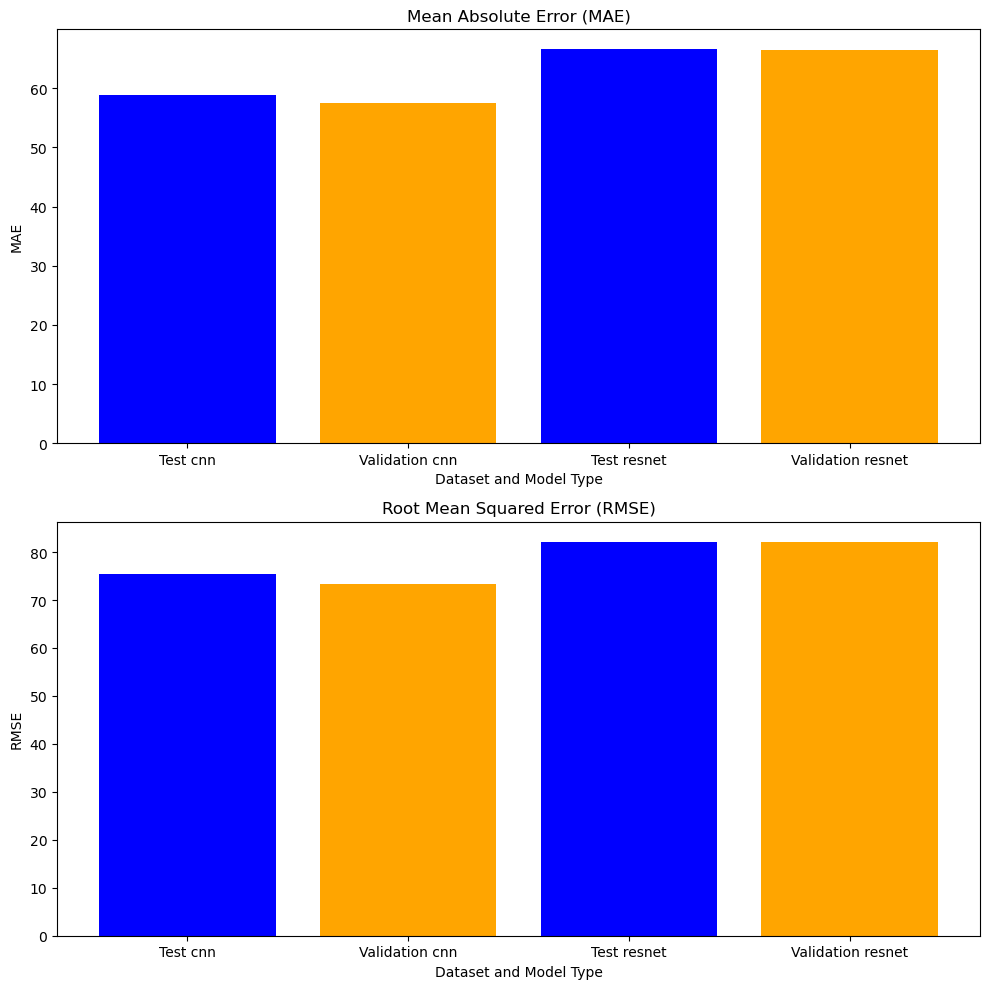

In [77]:
import matplotlib.pyplot as plt
import pandas as pd

# Data
data = {
    'dataset_name': ['Test', 'Validation', 'Test', 'Validation'],
    'model_type': ['cnn', 'cnn', 'resnet', 'resnet'],
    'mae': [58.82, 57.43, 66.63, 66.42],
    'rmse': [75.38, 73.38, 82.18, 82.20]
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Plotting
fig, ax = plt.subplots(2, 1, figsize=(10, 10))

# MAE Plot
ax[0].bar(df['dataset_name'] + " " + df['model_type'], df['mae'], color=['blue', 'orange', 'blue', 'orange'])
ax[0].set_title('Mean Absolute Error (MAE)')
ax[0].set_ylabel('MAE')
ax[0].set_xlabel('Dataset and Model Type')

# RMSE Plot
ax[1].bar(df['dataset_name'] + " " + df['model_type'], df['rmse'], color=['blue', 'orange', 'blue', 'orange'])
ax[1].set_title('Root Mean Squared Error (RMSE)')
ax[1].set_ylabel('RMSE')
ax[1].set_xlabel('Dataset and Model Type')

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()
